<a href="https://colab.research.google.com/github/MDAYAN0511/virtualwork-lab-internship-task2/blob/main/virtualwork_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Dataset Shape:", df.shape)
display(df.head())

Saving archive (1).zip to archive (1).zip
Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("\nDataset Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

In [5]:
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)


/tmp/ipykernel_2615/2481817300.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_2615/2481817300.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

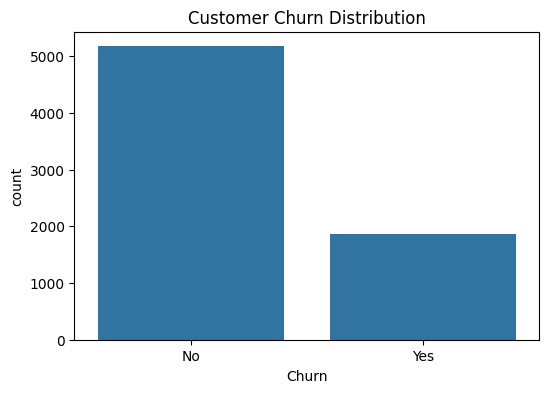


Churn Percentage
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [6]:
churn_col = "Churn"

plt.figure(figsize=(6,4))
sns.countplot(x=churn_col, data=df)
plt.title("Customer Churn Distribution")
plt.show()

print("\nChurn Percentage")
print(df[churn_col].value_counts(normalize=True)*100)

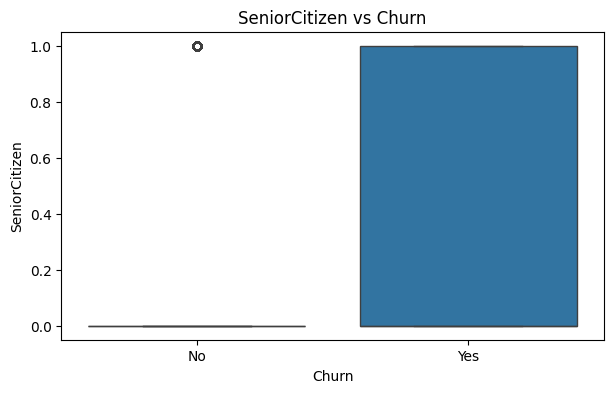

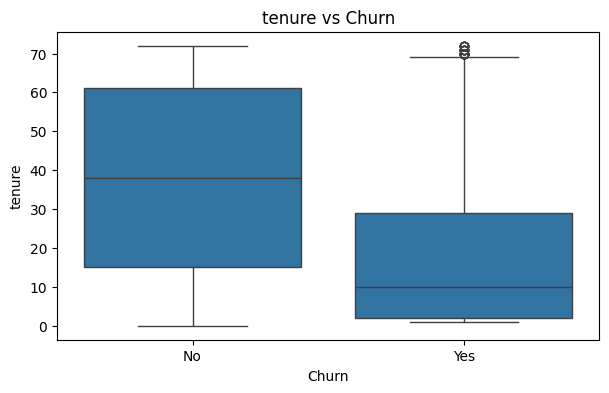

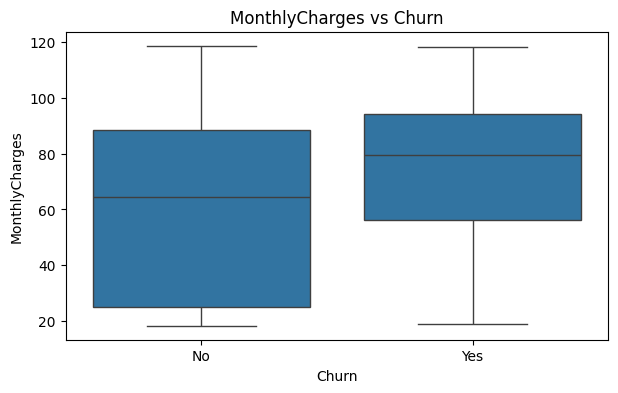

In [7]:

numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    if col != churn_col:

        plt.figure(figsize=(7,4))

        sns.boxplot(
            x=churn_col,
            y=col,
            data=df
        )

        plt.title(f"{col} vs Churn")
        plt.show()


<Figure size 800x400 with 0 Axes>

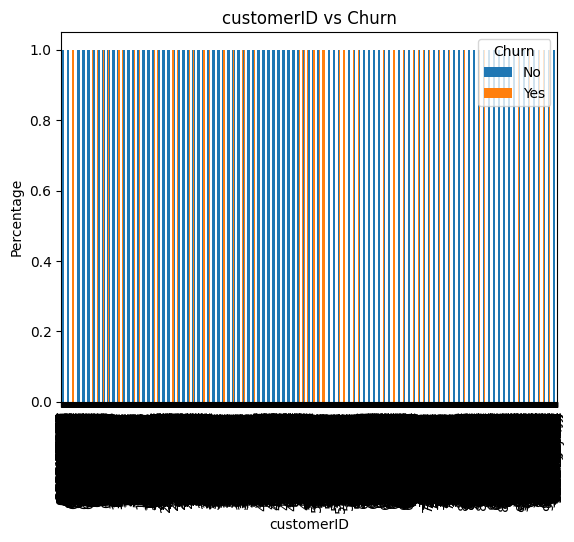

<Figure size 800x400 with 0 Axes>

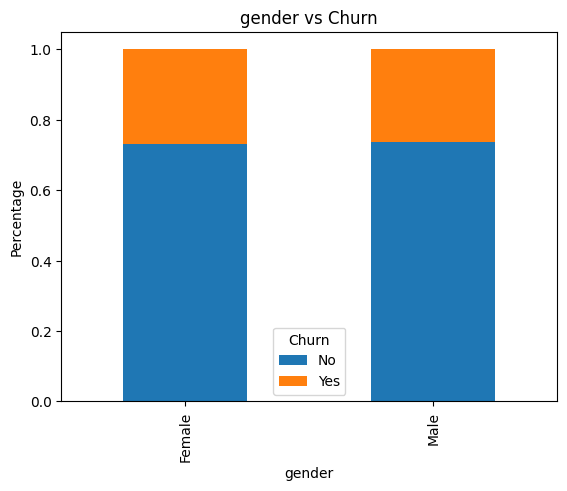

<Figure size 800x400 with 0 Axes>

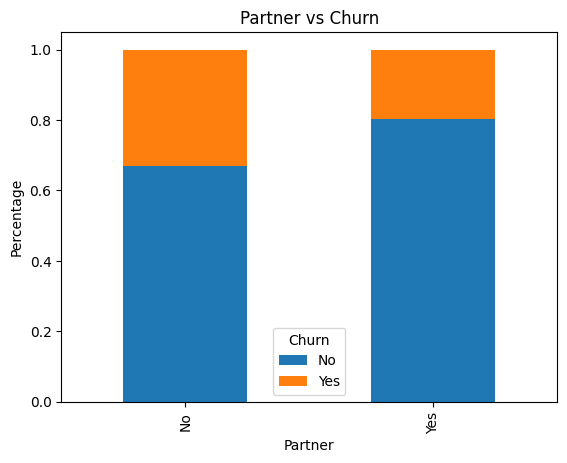

<Figure size 800x400 with 0 Axes>

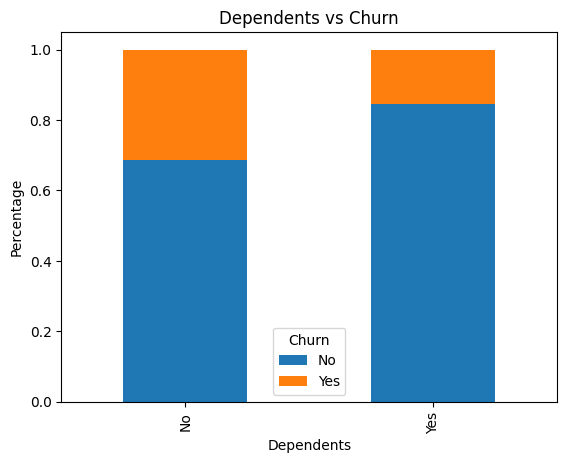

<Figure size 800x400 with 0 Axes>

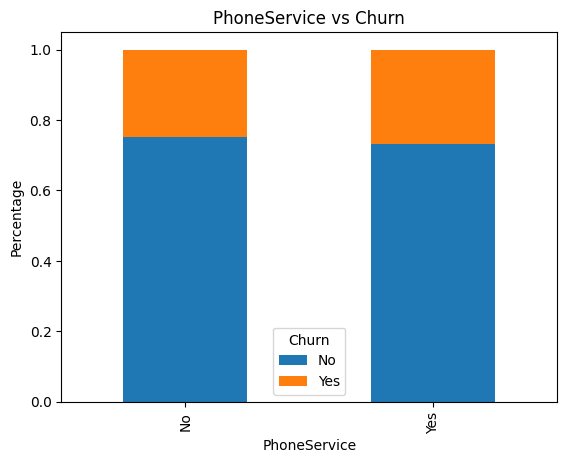

<Figure size 800x400 with 0 Axes>

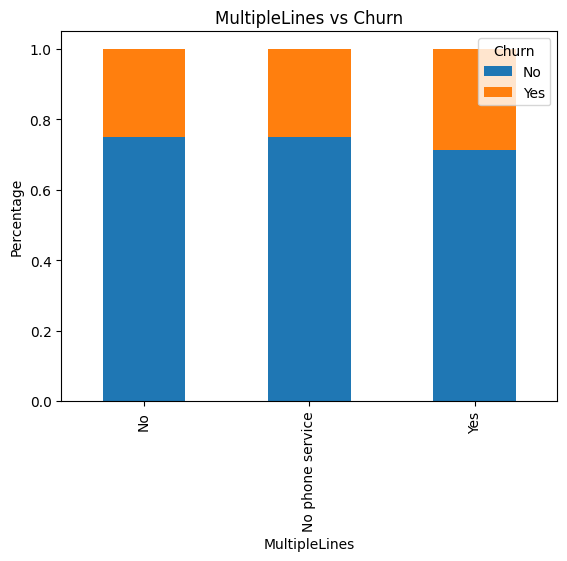

<Figure size 800x400 with 0 Axes>

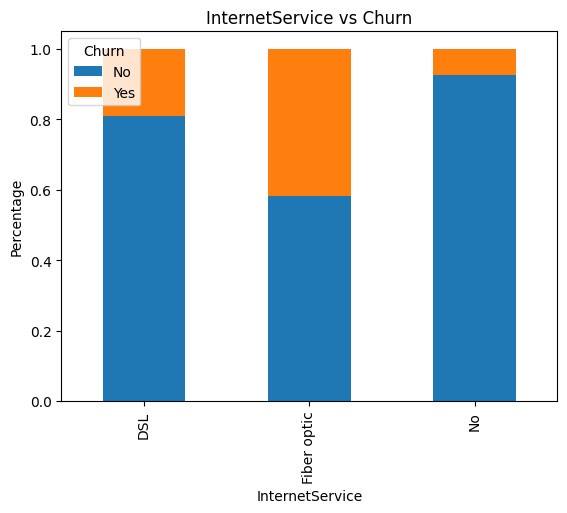

<Figure size 800x400 with 0 Axes>

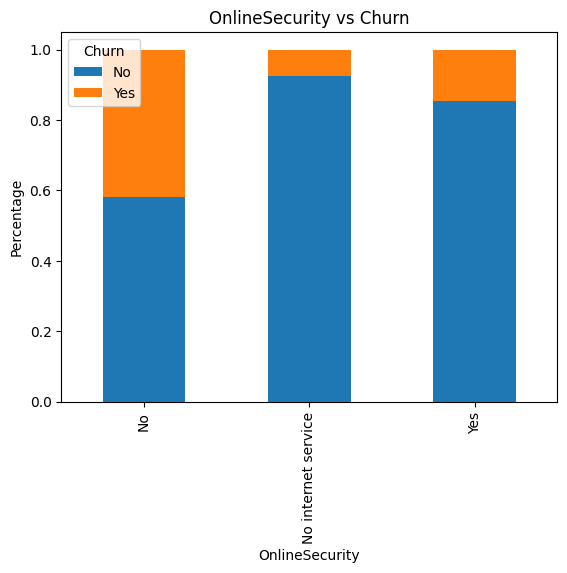

<Figure size 800x400 with 0 Axes>

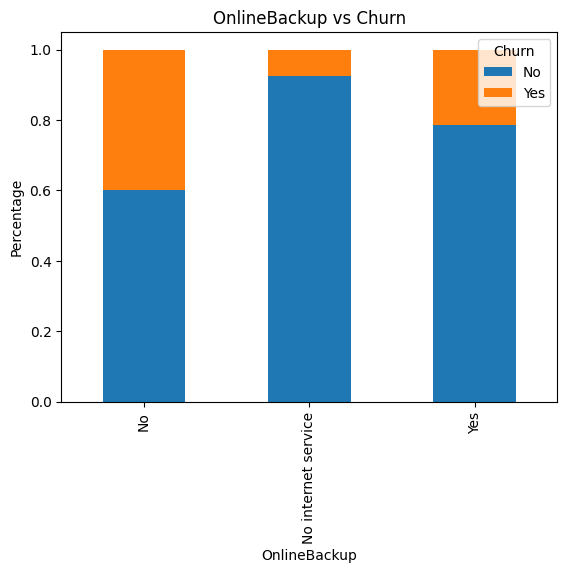

<Figure size 800x400 with 0 Axes>

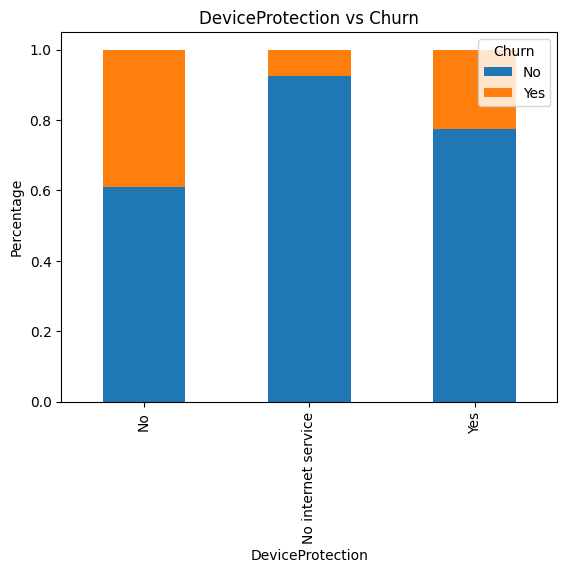

<Figure size 800x400 with 0 Axes>

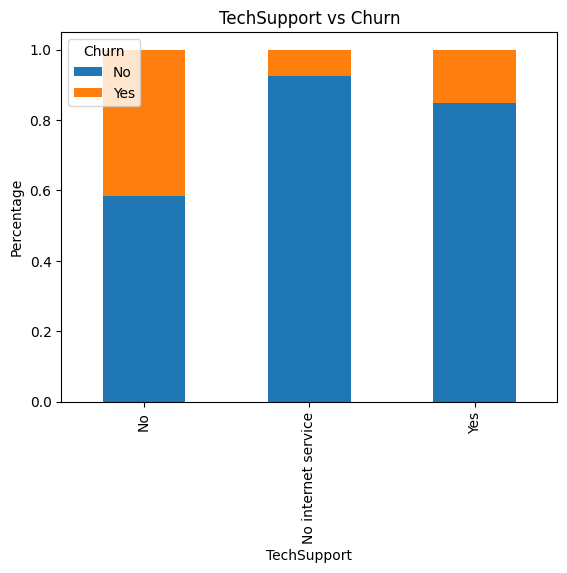

<Figure size 800x400 with 0 Axes>

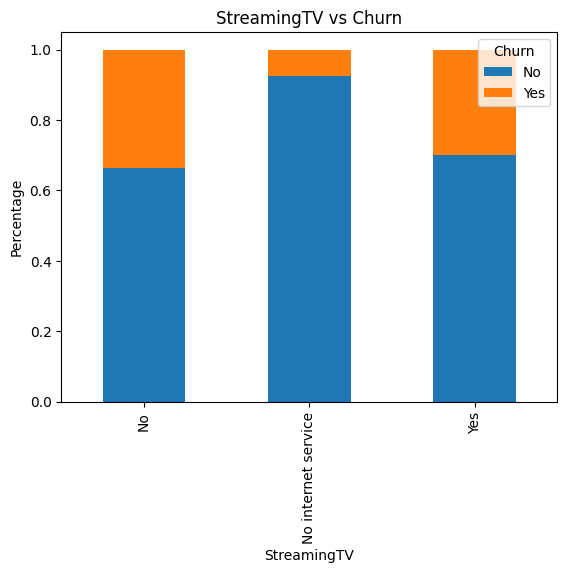

<Figure size 800x400 with 0 Axes>

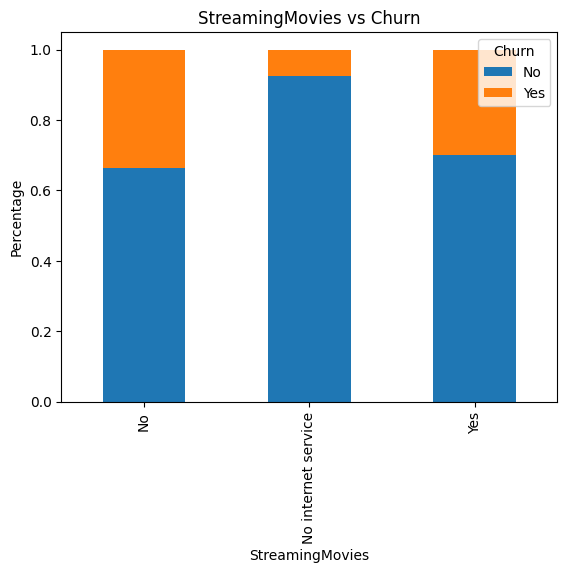

<Figure size 800x400 with 0 Axes>

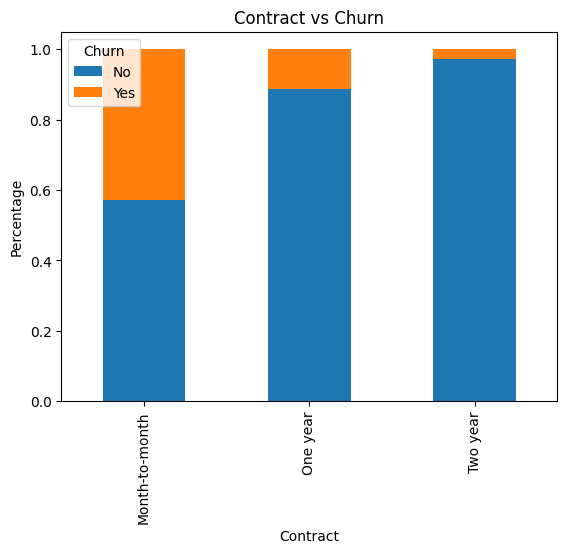

<Figure size 800x400 with 0 Axes>

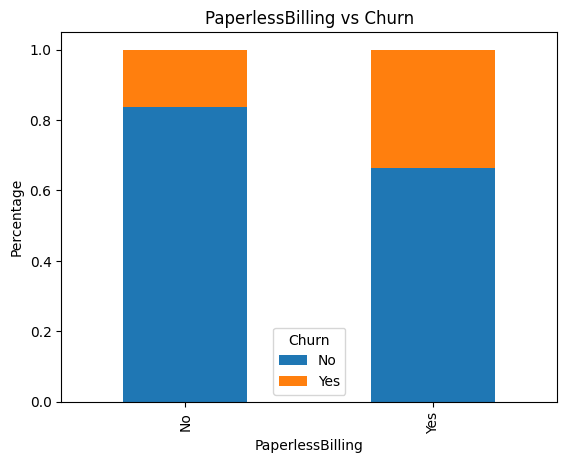

<Figure size 800x400 with 0 Axes>

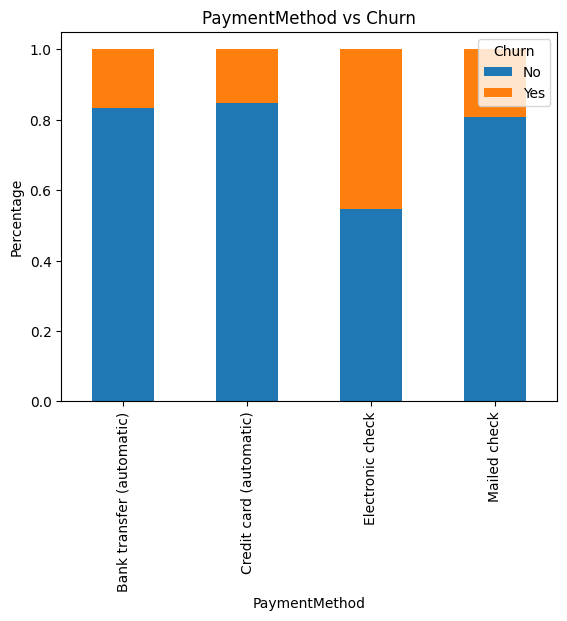

<Figure size 800x400 with 0 Axes>

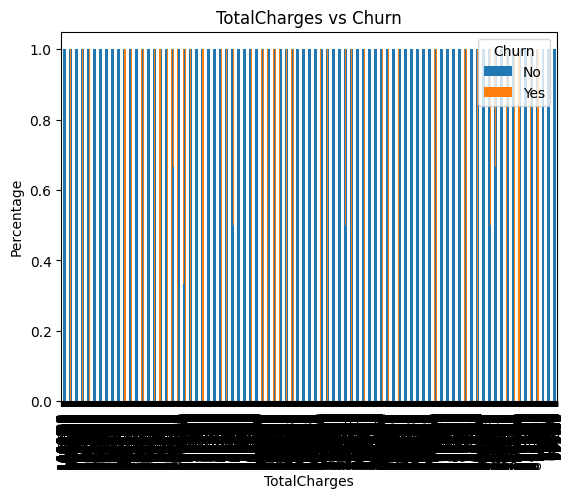

In [8]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:

    if col != churn_col:

        plt.figure(figsize=(8,4))

        churn_rate = pd.crosstab(
            df[col],
            df[churn_col],
            normalize='index'
        )

        churn_rate.plot(
            kind='bar',
            stacked=True
        )

        plt.title(f"{col} vs Churn")
        plt.ylabel("Percentage")
        plt.show()


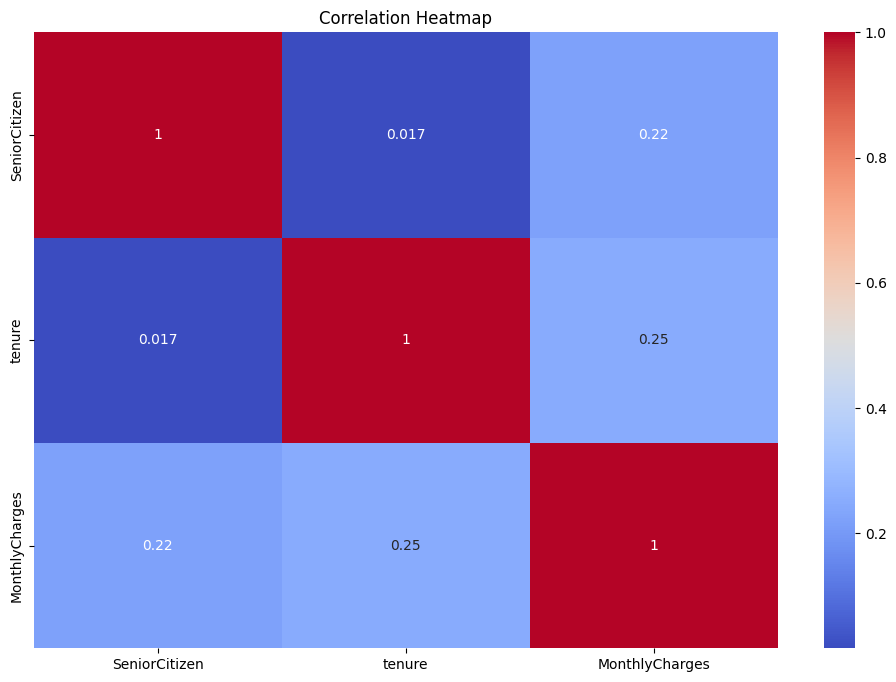

In [9]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

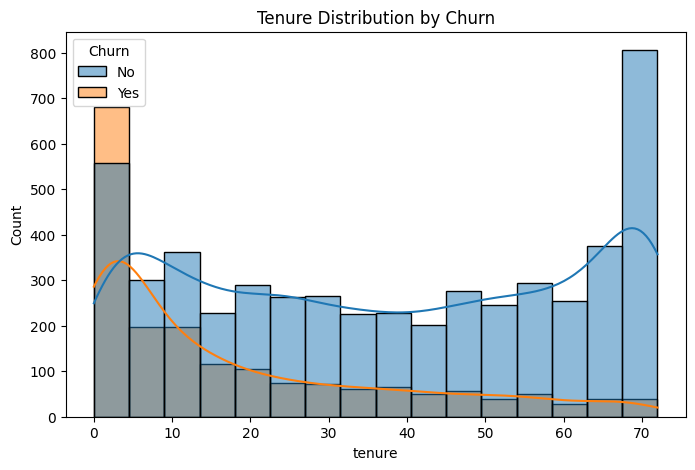

In [10]:
if 'tenure' in df.columns:

    plt.figure(figsize=(8,5))

    sns.histplot(
        data=df,
        x='tenure',
        hue=churn_col,
        kde=True
    )

    plt.title("Tenure Distribution by Churn")
    plt.show()

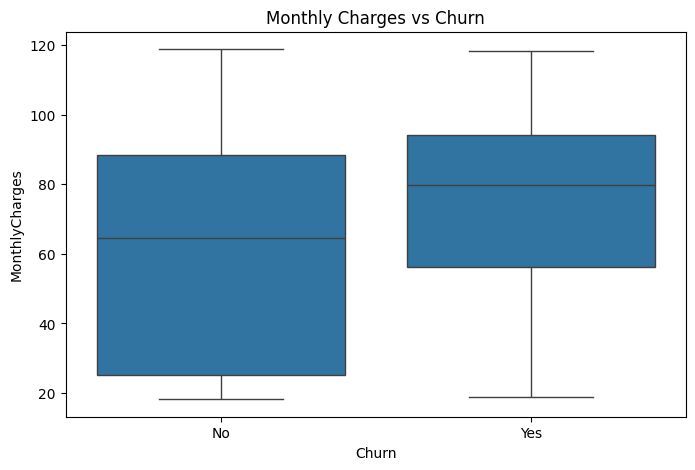

In [11]:
if 'MonthlyCharges' in df.columns:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        x=churn_col,
        y='MonthlyCharges',
        data=df
    )

    plt.title("Monthly Charges vs Churn")
    plt.show()

In [12]:
print("\nSummary Statistics")
display(df.describe())


Summary Statistics


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [13]:
print("""
=============================
CUSTOMER CHURN INSIGHTS
=============================

1. Analyze which customer groups have the highest churn.

2. Compare average tenure between churned
   and retained customers.

3. Identify whether higher monthly charges
   contribute to churn.

4. Examine service usage and engagement
   patterns among churned customers.

5. Focus retention campaigns on segments
   with the highest churn percentage.
""")


CUSTOMER CHURN INSIGHTS

1. Analyze which customer groups have the highest churn.

2. Compare average tenure between churned
   and retained customers.

3. Identify whether higher monthly charges
   contribute to churn.

4. Examine service usage and engagement
   patterns among churned customers.

5. Focus retention campaigns on segments
   with the highest churn percentage.

